<a href="https://colab.research.google.com/github/sumaiyaSultanaTarin/AML-nucleus-cytoplasm-segmentation/blob/main/AML_V3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Phase-A**

Environment setup

In [1]:
import random
import numpy as np
import torch

def set_seed(seed):
      random.seed(seed)
      np.random.seed(seed)
      torch.manual_seed(seed)
      torch.cuda.manual_seed_all(seed)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [4]:
from google.colab import drive
import os

drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/AML_segmentation_project"

DATA_DIR = os.path.join(PROJECT_DIR, "data")
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
LOG_DIR = os.path.join(PROJECT_DIR, "logs")

for d in [DATA_DIR, CHECKPOINT_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

print("Project folder:", PROJECT_DIR)
print("Data dir:", DATA_DIR)
print("Checkpoint dir:", CHECKPOINT_DIR)
print("Log dir:", LOG_DIR)

Mounted at /content/drive
Project folder: /content/drive/MyDrive/AML_segmentation_project
Data dir: /content/drive/MyDrive/AML_segmentation_project/data
Checkpoint dir: /content/drive/MyDrive/AML_segmentation_project/checkpoints
Log dir: /content/drive/MyDrive/AML_segmentation_project/logs


Install Packages

In [5]:
!pip install -q segmentation-models-pytorch albumentations huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.1 MB/s eta 0:00:00


Download and inspect WBCAtt+

In [6]:
from huggingface_hub import hf_hub_download
import tarfile
import os

LOCAL_DATA_DIR = "/content/data"
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

tar_path = hf_hub_download(
      repo_id="apple2373/wbcattplus",
      filename="pbcseg_final_v1.tar",
      repo_type="dataset",
      local_dir=LOCAL_DATA_DIR,
  )

print("Downloaded to:", tar_path)

with tarfile.open(tar_path) as tar:
      tar.extractall(LOCAL_DATA_DIR)

print("\nExtracted contents of", LOCAL_DATA_DIR, ":")
for root, dirs, files in os.walk(LOCAL_DATA_DIR):
      depth = root.replace(LOCAL_DATA_DIR, "").count(os.sep)
      if depth > 2:
          continue
      indent = "  " * depth
      print(f"{indent}{os.path.basename(root)}/")
      for f in files[:5]:
          print(f"{indent}  {f}")
      if len(files) > 5:
          print(f"{indent}  ... ({len(files)} files total)")

pbcseg_final_v1.tar: reconstructing file:   0%|          |  0.00B /  190MB            

pbcseg_final_v1.tar: downloading bytes:           |  0.00B            

Downloaded to: /content/data/pbcseg_final_v1.tar


/tmp/ipykernel_1156/781725178.py:18: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(LOCAL_DATA_DIR)



Extracted contents of /content/data :
data/
  pbcseg_final_v1.tar
  .cache/
    huggingface/
      .gitignore
      CACHEDIR.TAG
  pbcseg_final_v1/
    EO_655132_ccrop.jpg
    BNE_360309_ccrop_mask.png
    SNE_947090_ccrop.jpg
    EO_376623_ccrop_mask.png
    LY_979514_ccrop_mask.png
    ... (20596 files total)


Get the official split + inspect mask values

In [8]:
import pandas as pd
import numpy as np
from PIL import Image
import glob

base_url = "https://raw.githubusercontent.com/apple2373/wbcattplus/main/dataset_txt/"
split_csv_url = base_url + "pbc_attr_v1_ccrop_all.csv"

split_df = pd.read_csv(split_csv_url)

print("Split counts:")
print(split_df["split"].value_counts())
print("\nFirst few rows:")
print(split_df[["img_name", "split"]].head())

mask_paths = glob.glob(f"{LOCAL_DATA_DIR}/pbcseg_final_v1/*_mask.png")
sample_mask = np.array(Image.open(mask_paths[0]))

print("\nSample mask file:", mask_paths[0])
print("Mask shape:", sample_mask.shape)
print("Unique pixel values:", np.unique(sample_mask))

Split counts:
split
train    6169
test     3099
val      1030
Name: count, dtype: int64

First few rows:
             img_name  split
0  BNE_7323_ccrop.jpg  train
1  BNE_7938_ccrop.jpg  train
2  BNE_8741_ccrop.jpg  train
3  BNE_9071_ccrop.jpg  train
4  BNE_9373_ccrop.jpg  train

Sample mask file: /content/data/pbcseg_final_v1/BNE_360309_ccrop_mask.png
Mask shape: (360, 360)
Unique pixel values: [0 1 2 4]


**Phase-B**

Class remap, sanity-checked on the sample mask

Raw unique values: [0 1 2 4]
Remapped unique values: [0 1 2]


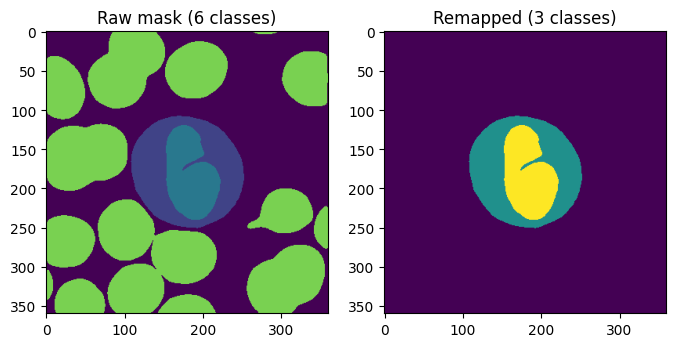

In [9]:
import matplotlib.pyplot as plt

# raw value -> 3-class label (0=background, 1=cytoplasm, 2=nucleus)
REMAP = np.array([0, 1, 2, 0, 0, 1], dtype=np.uint8)

def remap_mask(raw_mask):
      return REMAP[raw_mask]

remapped = remap_mask(sample_mask)

print("Raw unique values:", np.unique(sample_mask))
print("Remapped unique values:", np.unique(remapped))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample_mask, vmin=0, vmax=5)
axes[0].set_title("Raw mask (6 classes)")
axes[1].imshow(remapped, vmin=0, vmax=2)
axes[1].set_title("Remapped (3 classes)")
plt.show()

Dataset class (no augmentation yet)

In [10]:
import torch
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

basic_transform = A.Compose([
      A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
      ToTensorV2(),
])


class WBCAttDataset(Dataset):
    def __init__(self, split_df, split_name, image_dir, transform):
          self.df = split_df[split_df["split"] == split_name].reset_index(drop=True)
          self.image_dir = image_dir
          self.transform = transform

    def __len__(self):
          return len(self.df)

    def __getitem__(self, idx):
          img_name = self.df.loc[idx, "img_name"]
          image_path = self.image_dir + "/" + img_name
          mask_path = image_path.replace(".jpg", "_mask.png")

          image = np.array(Image.open(image_path).convert("RGB"))
          raw_mask = np.array(Image.open(mask_path))
          mask = remap_mask(raw_mask)

          transformed = self.transform(image=image, mask=mask)
          image_tensor = transformed["image"]
          mask_tensor = transformed["mask"].long()

          return image_tensor, mask_tensor


image_dir = LOCAL_DATA_DIR + "/pbcseg_final_v1"
train_dataset = WBCAttDataset(split_df, "train", image_dir, basic_transform)

print("Train dataset size:", len(train_dataset))
img, msk = train_dataset[0]
print("Image tensor shape:", img.shape, img.dtype)
print("Mask tensor shape:", msk.shape, msk.dtype)
print("Mask unique values:", torch.unique(msk))

Train dataset size: 6169
Image tensor shape: torch.Size([3, 360, 360]) torch.float32
Mask tensor shape: torch.Size([360, 360]) torch.int64
Mask unique values: tensor([0, 1, 2])


Augmentation + DataLoaders

In [14]:
import cv2
from torch.utils.data import DataLoader

train_transform = A.Compose([
      A.HorizontalFlip(p=0.5),
      A.VerticalFlip(p=0.5),
      A.Rotate(limit=15, border_mode=cv2.BORDER_CONSTANT,
                fill=0, fill_mask=0, p=0.5),
      A.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05, p=0.5),
      A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
      ToTensorV2(),
])

train_dataset = WBCAttDataset(split_df, "train", image_dir, train_transform)
val_dataset = WBCAttDataset(split_df, "val", image_dir, basic_transform)
test_dataset = WBCAttDataset(split_df, "test", image_dir, basic_transform)

print("train:", len(train_dataset), "val:", len(val_dataset), "test:",
len(test_dataset))

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=2, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=2, pin_memory=True, persistent_workers=True)

images, masks = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch mask shape:", masks.shape)
print("Batch mask unique values:", torch.unique(masks))

train: 6169 val: 1030 test: 3099
Batch image shape: torch.Size([16, 3, 360, 360])
Batch mask shape: torch.Size([16, 360, 360])
Batch mask unique values: tensor([0, 1, 2])


**Phase-C**

Model with RFG init

In [15]:
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp


class RatioFeedbackGate(nn.Module):
      def __init__(self, channels, hidden=8, epsilon=1e-6, init_bias=-4.0):
          super().__init__()
          self.epsilon = epsilon
          self.probe_head = nn.Conv2d(channels, 3, kernel_size=1)
          self.fc1 = nn.Linear(1, hidden)
          self.fc2 = nn.Linear(hidden, channels)

          nn.init.zeros_(self.fc2.weight)
          nn.init.constant_(self.fc2.bias, init_bias)

          self.last_ratio = None
          self.last_gate_mean = None

      def forward(self, x):
          probe = F.softmax(self.probe_head(x), dim=1)
          nuc_area = probe[:, 2, :, :].sum(dim=[1, 2])
          cyto_area = probe[:, 1, :, :].sum(dim=[1, 2])
          ratio = torch.log((nuc_area + self.epsilon) / (cyto_area + self.epsilon))
          self.last_ratio = ratio

          h = F.relu(self.fc1(ratio.unsqueeze(1)))
          gate = torch.sigmoid(self.fc2(h))
          self.last_gate_mean = gate.mean().item()

          gate = gate.view(gate.size(0), gate.size(1), 1, 1)
          return x + x * gate


class SegModel(nn.Module):
      def __init__(self, backbone, num_classes=3, use_rfg=True):
          super().__init__()
          if backbone == "attention_unet":
              base = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                               decoder_attention_type="scse", in_channels=3,
classes=num_classes)
          elif backbone == "unet":
              base = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                               in_channels=3, classes=num_classes)
          else:
              raise ValueError("unknown backbone: " + backbone)

          self.encoder = base.encoder
          self.decoder = base.decoder
          self.seg_head = base.segmentation_head
          self.use_rfg = use_rfg
          if use_rfg:
              channels = self.seg_head[0].in_channels
              self.rfg = RatioFeedbackGate(channels)

      def forward(self, x):
          features = self.encoder(x)
          d = self.decoder(features)
          if self.use_rfg:
              d = self.rfg(d)
          return self.seg_head(d)

model = SegModel("attention_unet", num_classes=3, use_rfg=True).to(device)
images_gpu = images.to(device)

with torch.no_grad():
      output = model(images_gpu)

print("Output shape:", output.shape)
print("Gate mean at init:", model.rfg.last_gate_mean)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Output shape: torch.Size([16, 3, 360, 360])
Gate mean at init: 0.01798621006309986


Losses + λ2 ramp schedule

In [16]:
class DiceLoss(nn.Module):
    def __init__(self, epsilon=1e-6):
          super().__init__()
          self.epsilon = epsilon

    def forward(self, logits, targets):
          probs = F.softmax(logits, dim=1)
          num_classes = probs.shape[1]
          targets_onehot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()
          dims = (0, 2, 3)
          intersection = torch.sum(probs * targets_onehot, dims)
          union = torch.sum(probs + targets_onehot, dims)
          dice_per_class = (2 * intersection + self.epsilon) / (union + self.epsilon)
          return 1 - dice_per_class.mean()


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
          super().__init__()
          self.gamma = gamma

    def forward(self, logits, targets):
          ce = F.cross_entropy(logits, targets, reduction="none")
          pt = torch.exp(-ce)
          return (((1 - pt) ** self.gamma) * ce).mean()


class RatioConsistencyLoss(nn.Module):
    def __init__(self, epsilon=1e-6):
          super().__init__()
          self.epsilon = epsilon
          self.huber = nn.HuberLoss()

    def true_log_ratio(self, targets):
          true_nuc = (targets == 2).float().sum(dim=[1, 2])
          true_cyto = (targets == 1).float().sum(dim=[1, 2])
          return torch.log((true_nuc + self.epsilon) / (true_cyto + self.epsilon))

    def forward(self, logits, targets):
          probs = F.softmax(logits, dim=1)
          pred_nuc = probs[:, 2, :, :].sum(dim=[1, 2])
          pred_cyto = probs[:, 1, :, :].sum(dim=[1, 2])
          pred_ratio = torch.log((pred_nuc + self.epsilon) / (pred_cyto + self.epsilon))
          true_ratio = self.true_log_ratio(targets)
          return self.huber(pred_ratio, true_ratio)


def lambda2_ramp(epoch, total_epochs, target=0.3, ramp_fraction=0.25):
      """Linearly ramps the ratio-loss weight from 0 to target over the
      first `ramp_fraction` of training, instead of applying full weight
      from epoch 1."""
      ramp_epochs = max(1, int(total_epochs * ramp_fraction))
      if epoch >= ramp_epochs:
          return target
      return target * (epoch / ramp_epochs)


class TotalLoss(nn.Module):
    def __init__(self, lambda1=0.5, lambda3=0.3):
          super().__init__()
          self.dice = DiceLoss()
          self.focal = FocalLoss()
          self.ratio = RatioConsistencyLoss()
          self.rfg_huber = nn.HuberLoss()
          self.lambda1 = lambda1
          self.lambda3 = lambda3

    def forward(self, logits, targets, lambda2, rfg_ratio=None):
          loss = self.dice(logits, targets) + self.lambda1 * self.focal(logits, targets)
          if lambda2 > 0:
              loss = loss + lambda2 * self.ratio(logits, targets)
          if rfg_ratio is not None:
              true_ratio = self.ratio.true_log_ratio(targets)
              loss = loss + self.lambda3 * self.rfg_huber(rfg_ratio, true_ratio)
          return loss


masks_gpu = masks.to(device)
loss_fn = TotalLoss()

lambda2_epoch0 = lambda2_ramp(epoch=0, total_epochs=20)
lambda2_epoch10 = lambda2_ramp(epoch=10, total_epochs=20)
print("lambda2 at epoch 0:", lambda2_epoch0)
print("lambda2 at epoch 10:", lambda2_epoch10)

with torch.no_grad():
    output = model(images_gpu)
loss = loss_fn(output, masks_gpu, lambda2=lambda2_epoch0,
rfg_ratio=model.rfg.last_ratio)
print("Loss at epoch 0:", loss.item())

lambda2 at epoch 0: 0.0
lambda2 at epoch 10: 0.3
Loss at epoch 0: 1.2574987411499023


Small-subset setup + training/eval functions

In [23]:
def evaluate(model, loader):
      model.eval()
      dice_metric = DiceLoss()
      total_dice = 0
      total_ratio_error = 0
      n_batches = 0

      with torch.no_grad():
          for imgs, msks in loader:
              imgs = imgs.to(device)
              msks = msks.to(device)
              logits = model(imgs)
              dice = 1 - dice_metric(logits, msks).item()

              probs = F.softmax(logits, dim=1)
              pred_nuc = probs[:, 2].sum(dim=[1, 2])
              pred_cyto = probs[:, 1].sum(dim=[1, 2])
              pred_ratio = torch.log((pred_nuc + 1e-6) / (pred_cyto + 1e-6))

              true_nuc = (msks == 2).float().sum(dim=[1, 2])
              true_cyto = (msks == 1).float().sum(dim=[1, 2])
              true_ratio = torch.log((true_nuc + 1e-6) / (true_cyto + 1e-6))

              ratio_error = (pred_ratio - true_ratio).abs().mean().item()

              total_dice += dice
              total_ratio_error += ratio_error
              n_batches += 1

      avg_dice = total_dice / n_batches
      avg_ratio_error = total_ratio_error / n_batches
      return avg_dice, avg_ratio_error


def quick_train(use_rfg, use_ratio, seed, train_loader, val_loader, epochs=10):
      torch.manual_seed(seed)
      model = SegModel("attention_unet", use_rfg=use_rfg).to(device)
      loss_fn = TotalLoss()
      opt = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

      history = []
      for epoch in range(epochs):
          model.train()
          lambda2 = 0.0
          if use_ratio:
              lambda2 = lambda2_ramp(epoch, epochs)

          for imgs, msks in train_loader:
              imgs = imgs.to(device)
              msks = msks.to(device)
              opt.zero_grad()
              logits = model(imgs)
              rfg_ratio = None
              if use_rfg:
                  rfg_ratio = model.rfg.last_ratio
              loss = loss_fn(logits, msks, lambda2=lambda2, rfg_ratio=rfg_ratio)
              loss.backward()
              opt.step()

          val_dice, val_ratio_error = evaluate(model, val_loader)
          row = {"epoch": epoch, "val_dice": val_dice, "val_ratio_error":
  val_ratio_error}
          history.append(row)
          print("epoch", epoch, "dice", round(val_dice, 4), "ratio_error",
  round(val_ratio_error, 4))

      return history


print("functions defined")

functions defined


In [24]:
import random as pyrandom
from torch.utils.data import Subset

pyrandom.seed(0)
train_idx = pyrandom.sample(range(len(train_dataset)), 600)
val_idx = pyrandom.sample(range(len(val_dataset)), 200)

small_train_loader = DataLoader(
      Subset(train_dataset, train_idx),
      batch_size=16,
      shuffle=True,
      num_workers=2,
      pin_memory=True,
      persistent_workers=True,
)

small_val_loader = DataLoader(
      Subset(val_dataset, val_idx),
      batch_size=16,
      shuffle=False,
      num_workers=2,
      pin_memory=True,
      persistent_workers=True,
)

print("train subset size", len(train_idx))
print("val subset size", len(val_idx))

train subset size 600
val subset size 200


In [25]:
print("=== baseline (no RFG, no ratio loss) ===")
baseline_history = quick_train(
      use_rfg=False,
      use_ratio=False,
      seed=1,
      train_loader=small_train_loader,
      val_loader=small_val_loader,
      epochs=10,
  )

print("")
print("=== full method (fixed RFG init + lambda2 ramp) ===")
full_history = quick_train(
      use_rfg=True,
      use_ratio=True,
      seed=1,
      train_loader=small_train_loader,
      val_loader=small_val_loader,
      epochs=10,
  )

print("")
print("final baseline: dice", round(baseline_history[-1]["val_dice"], 4),
        "ratio_error", round(baseline_history[-1]["val_ratio_error"], 4))
print("final full method: dice", round(full_history[-1]["val_dice"], 4),
        "ratio_error", round(full_history[-1]["val_ratio_error"], 4))

=== baseline (no RFG, no ratio loss) ===
epoch 0 dice 0.473 ratio_error 0.7057
epoch 1 dice 0.6518 ratio_error 0.6667
epoch 2 dice 0.7576 ratio_error 0.5602
epoch 3 dice 0.8416 ratio_error 0.3503
epoch 4 dice 0.8833 ratio_error 0.2545
epoch 5 dice 0.9049 ratio_error 0.1993
epoch 6 dice 0.9252 ratio_error 0.1322
epoch 7 dice 0.9348 ratio_error 0.162
epoch 8 dice 0.9447 ratio_error 0.0763
epoch 9 dice 0.9438 ratio_error 0.0873

=== full method (fixed RFG init + lambda2 ramp) ===
epoch 0 dice 0.433 ratio_error 0.6857
epoch 1 dice 0.6365 ratio_error 0.4138
epoch 2 dice 0.7557 ratio_error 0.3324
epoch 3 dice 0.8432 ratio_error 0.2311
epoch 4 dice 0.8782 ratio_error 0.2092
epoch 5 dice 0.903 ratio_error 0.1313
epoch 6 dice 0.9161 ratio_error 0.1158
epoch 7 dice 0.9246 ratio_error 0.1261
epoch 8 dice 0.938 ratio_error 0.0953
epoch 9 dice 0.9468 ratio_error 0.0826

final baseline: dice 0.9438 ratio_error 0.0873
final full method: dice 0.9468 ratio_error 0.0826


**Phase-D**

full-size DataLoaders

In [27]:
full_train_loader = DataLoader(
      train_dataset,
      batch_size=24,
      shuffle=True,
      num_workers=2,
      pin_memory=True,
      persistent_workers=True,
  )

full_val_loader = DataLoader(
      val_dataset,
      batch_size=24,
      shuffle=False,
      num_workers=2,
      pin_memory=True,
      persistent_workers=True,
  )

print("train batches per epoch:", len(full_train_loader))
print("val batches per epoch:", len(full_val_loader))

train batches per epoch: 258
val batches per epoch: 43


training function

In [28]:
import os
import pandas as pd
from torch.amp import autocast, GradScaler

In [32]:
def train_one_epoch(model, loader, loss_fn, opt, scaler, lambda2, use_rfg):
      model.train()
      total_loss = 0
      n_batches = 0

      for imgs, msks in loader:
          imgs = imgs.to(device)
          msks = msks.to(device)
          opt.zero_grad()

          with autocast("cuda"):
              logits = model(imgs)
              rfg_ratio = None
              if use_rfg:
                  rfg_ratio = model.rfg.last_ratio
              loss = loss_fn(logits, msks, lambda2=lambda2, rfg_ratio=rfg_ratio)

          scaler.scale(loss).backward()
          scaler.step(opt)
          scaler.update()

          total_loss += loss.item()
          n_batches += 1

      return total_loss / n_batches

In [33]:
def run_experiment(backbone, use_rfg, use_ratio, seed,
                      train_loader, val_loader,
                      max_epochs=50, patience=8):

      torch.manual_seed(seed)

      run_name = backbone
      run_name += "_rfg" + str(int(use_rfg))
      run_name += "_ratio" + str(int(use_ratio))
      run_name += "_seed" + str(seed)

      checkpoint_path = os.path.join(CHECKPOINT_DIR, run_name + ".pt")
      state_path = os.path.join(CHECKPOINT_DIR, run_name + "_state.pt")

      model = SegModel(backbone, num_classes=3, use_rfg=use_rfg).to(device)
      loss_fn = TotalLoss()
      opt = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
      scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
      scaler = GradScaler("cuda")

      start_epoch = 0
      best_dice = 0
      best_ratio_error = float("inf")
      epochs_no_improve = 0
      history = []

      if os.path.exists(state_path):
          state = torch.load(state_path, map_location=device)
          model.load_state_dict(state["model"])
          opt.load_state_dict(state["optimizer"])
          scheduler.load_state_dict(state["scheduler"])
          scaler.load_state_dict(state["scaler"])
          start_epoch = state["epoch"]
          best_dice = state["best_dice"]
          best_ratio_error = state["best_ratio_error"]
          epochs_no_improve = state["epochs_no_improve"]
          history = state["history"]
          print("resuming", run_name, "from epoch", start_epoch)
      else:
          print("starting", run_name)

      for epoch in range(start_epoch, max_epochs):
          lambda2 = 0.0
          if use_ratio:
              lambda2 = lambda2_ramp(epoch, max_epochs)

          train_loss = train_one_epoch(model, train_loader, loss_fn, opt, scaler,
  lambda2, use_rfg)
          scheduler.step()

          val_dice, val_ratio_error = evaluate(model, val_loader)
          print("epoch", epoch + 1, "train_loss", round(train_loss, 4),
                "val_dice", round(val_dice, 4), "val_ratio_error",
  round(val_ratio_error, 4))

          history.append({"epoch": epoch + 1, "train_loss": train_loss,
                           "val_dice": val_dice, "val_ratio_error": val_ratio_error})

          if val_ratio_error < best_ratio_error:
              best_dice = val_dice
              best_ratio_error = val_ratio_error
              epochs_no_improve = 0
              torch.save(model.state_dict(), checkpoint_path)
          else:
              epochs_no_improve += 1

          state = {"model": model.state_dict(), "optimizer": opt.state_dict(),
                   "scheduler": scheduler.state_dict(), "scaler": scaler.state_dict(),
                   "epoch": epoch + 1, "best_dice": best_dice,
                   "best_ratio_error": best_ratio_error,
                   "epochs_no_improve": epochs_no_improve, "history": history}
          torch.save(state, state_path)

          if epochs_no_improve >= patience:
              print("early stopping at epoch", epoch + 1)
              break

      history_df = pd.DataFrame(history)
      history_path = os.path.join(LOG_DIR, run_name + "_history.csv")
      history_df.to_csv(history_path, index=False)

      if os.path.exists(state_path):
          os.remove(state_path)

      print("finished", run_name)
      print("best_dice", best_dice, "best_ratio_error", best_ratio_error)

      return {"run_name": run_name, "backbone": backbone, "use_rfg": use_rfg,
              "use_ratio": use_ratio, "seed": seed, "best_dice": best_dice,
              "best_ratio_error": best_ratio_error, "checkpoint_path": checkpoint_path,
              "history_path": history_path}

In [34]:
import time

start_time = time.time()

timing_result = run_experiment(
      backbone="attention_unet",
      use_rfg=False,
      use_ratio=False,
      seed=999,
      train_loader=full_train_loader,
      val_loader=full_val_loader,
      max_epochs=2,
      patience=2,
  )

elapsed = time.time() - start_time
print("total seconds for 2 epochs:", round(elapsed, 1))
print("seconds per epoch:", round(elapsed / 2, 1))
print("minutes per epoch:", round(elapsed / 2 / 60, 2))

starting attention_unet_rfg0_ratio0_seed999
epoch 1 train_loss 0.3056 val_dice 0.9059 val_ratio_error 0.1285
epoch 2 train_loss 0.0757 val_dice 0.9505 val_ratio_error 0.0811
finished attention_unet_rfg0_ratio0_seed999
best_dice 0.9504763622616612 best_ratio_error 0.08111580560893514
total seconds for 2 epochs: 271.6
seconds per epoch: 135.8
minutes per epoch: 2.26
